# Rossmann Store Sales - Feature Engineering & Modélisation

**Pipeline :**
1. Feature engineering (date, lag, rolling, encodage)
2. Entraînement LightGBM
3. Évaluation (RMSPE)
4. Génération du fichier de soumission

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('.'))

import pandas as pd
import numpy as np
import lightgbm as lgb
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from src.features import (
    load_and_merge, clean, add_date_features,
    add_lag_features, add_rolling_features,
    encode_categoricals, FEATURE_COLS
)
from src.evaluate import rmspe, rmspe_lgb, plot_feature_importance, plot_predictions

DATASET = 'dataset/'
SEED = 42

## 1. Chargement & nettoyage

In [2]:
train_raw, test_raw = load_and_merge(
    DATASET + 'train.csv',
    DATASET + 'store.csv',
    DATASET + 'test.csv'
)

train_raw = clean(train_raw)
print(f'Train après nettoyage : {train_raw.shape}')

Train après nettoyage : (844338, 18)


## 2. Feature Engineering

In [3]:
# Concaténer train + test pour les features de lag/rolling (évite le data leakage sur test)
test_raw['Sales'] = np.nan
test_raw['Customers'] = np.nan

combined = pd.concat([train_raw, test_raw], sort=False).reset_index(drop=True)
combined = add_date_features(combined)
combined = add_lag_features(combined, lags=(7, 14, 21, 28))
combined = add_rolling_features(combined, windows=(7, 14, 28))
combined = encode_categoricals(combined)

train = combined[combined['Sales'].notna()].copy()
test  = combined[combined['Sales'].isna()].copy()

print(f'Train features: {train.shape}  |  Test features: {test.shape}')

Train features: (844338, 37)  |  Test features: (41088, 37)


## 3. Transformation de la cible (log)

In [4]:
train['log_Sales'] = np.log1p(train['Sales'])

# Supprimer les lignes avec des NaN dans les features (dues aux lags)
lag_cols = [c for c in FEATURE_COLS if 'lag' in c or 'roll' in c]
train = train.dropna(subset=lag_cols)
print(f'Train après suppression NaN lags : {train.shape}')

Train après suppression NaN lags : (813118, 38)


## 4. Split train / validation

In [5]:
# Validation = 6 dernières semaines (approche temporelle)
cutoff = train['Date'].max() - pd.Timedelta(weeks=6)

X_train = train[train['Date'] <= cutoff][FEATURE_COLS]
y_train = train[train['Date'] <= cutoff]['log_Sales']

X_val = train[train['Date'] > cutoff][FEATURE_COLS]
y_val = train[train['Date'] > cutoff]['log_Sales']
y_val_raw = train[train['Date'] > cutoff]['Sales']

print(f'Train : {X_train.shape}  |  Val : {X_val.shape}')
print(f'Cutoff date : {cutoff.date()}')

Train : (772836, 27)  |  Val : (40282, 27)
Cutoff date : 2015-06-19


## 5. Entraînement LightGBM

In [6]:
dtrain = lgb.Dataset(X_train, label=y_train)
dval   = lgb.Dataset(X_val,   label=y_val, reference=dtrain)

params = {
    'objective': 'regression_l2',
    'metric': 'rmse',
    'learning_rate': 0.05,
    'num_leaves': 127,
    'min_child_samples': 20,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'lambda_l1': 0.1,
    'lambda_l2': 0.1,
    'verbose': -1,
    'seed': SEED,
    'n_jobs': -1,
}

callbacks = [
    lgb.early_stopping(stopping_rounds=50, verbose=True),
    lgb.log_evaluation(period=100)
]

model = lgb.train(
    params,
    dtrain,
    num_boost_round=2000,
    valid_sets=[dval],
    callbacks=callbacks,
    feval=rmspe_lgb
)

Training until validation scores don't improve for 50 rounds
[100]	valid_0's rmse: 0.130333	valid_0's rmspe: 0.140245
[200]	valid_0's rmse: 0.122255	valid_0's rmspe: 0.13014
[300]	valid_0's rmse: 0.119786	valid_0's rmspe: 0.127055
[400]	valid_0's rmse: 0.118178	valid_0's rmspe: 0.125627
[500]	valid_0's rmse: 0.116671	valid_0's rmspe: 0.124119
[600]	valid_0's rmse: 0.11543	valid_0's rmspe: 0.12284
[700]	valid_0's rmse: 0.114374	valid_0's rmspe: 0.121558
[800]	valid_0's rmse: 0.113845	valid_0's rmspe: 0.120931
[900]	valid_0's rmse: 0.113344	valid_0's rmspe: 0.120304
[1000]	valid_0's rmse: 0.113021	valid_0's rmspe: 0.119798
[1100]	valid_0's rmse: 0.112692	valid_0's rmspe: 0.119577
Early stopping, best iteration is:
[1145]	valid_0's rmse: 0.112595	valid_0's rmspe: 0.11941


## 6. Évaluation sur le set de validation

In [7]:
preds_val_log = model.predict(X_val)
preds_val = np.expm1(preds_val_log).clip(min=0)

score = rmspe(y_val_raw.values, preds_val)
print(f'RMSPE validation : {score:.4f}')
print(f'RMSPE en % : {score*100:.2f}%')

RMSPE validation : 0.1194
RMSPE en % : 11.94%


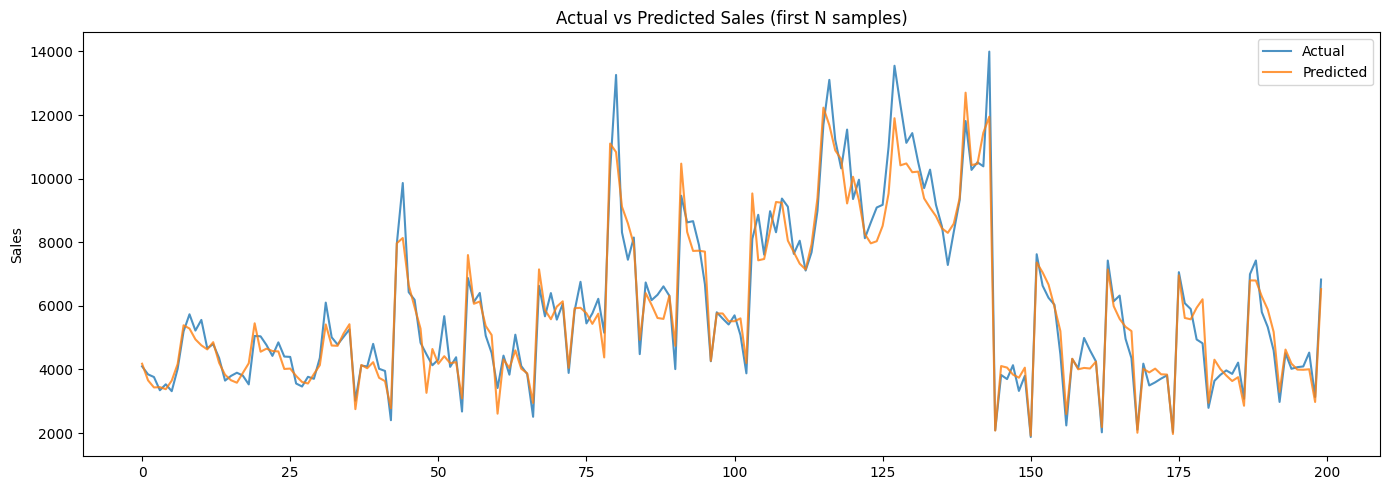

In [8]:
fig = plot_predictions(y_val_raw.reset_index(drop=True), preds_val)
plt.show()

## 7. Feature Importance

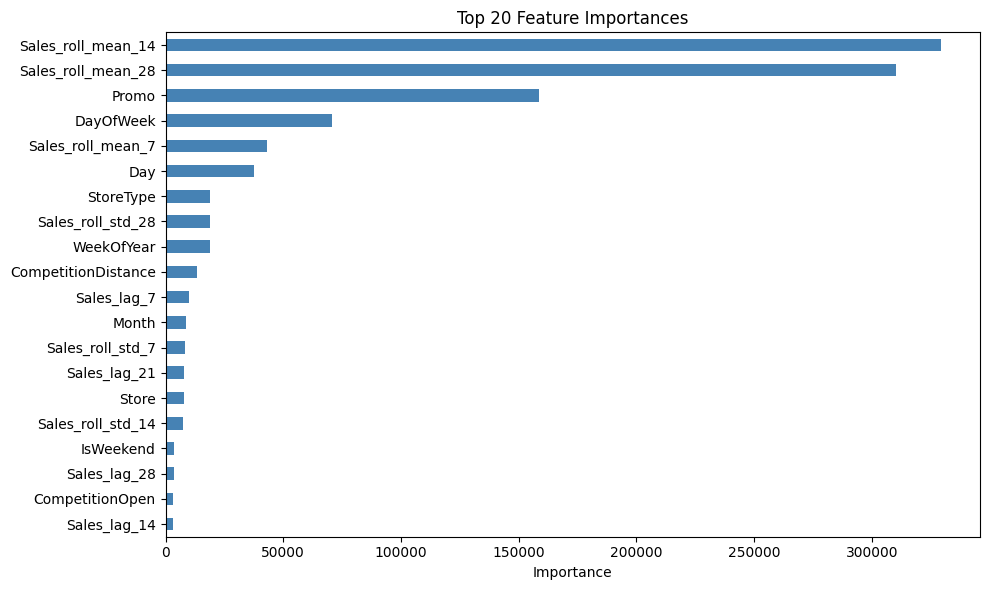

In [9]:
fig = plot_feature_importance(model, FEATURE_COLS, top_n=20)
plt.show()

## 8. Prédictions sur le test set & soumission

In [10]:
# Ré-entraîner sur tout le train avant de prédire sur test
X_all = train[FEATURE_COLS]
y_all = train['log_Sales']

dall = lgb.Dataset(X_all, label=y_all)

# Utiliser le best_iteration trouvé lors de la validation
best_iter = model.best_iteration
final_model = lgb.train(params, dall, num_boost_round=best_iter)

print(f'Modèle final entraîné avec {best_iter} itérations')

Modèle final entraîné avec 1145 itérations


In [11]:
X_test = test[FEATURE_COLS].fillna(0)
test_preds = np.expm1(final_model.predict(X_test)).clip(min=0)

# Les stores fermés ont Sales = 0
test_preds[test['Open'].fillna(1) == 0] = 0

submission = pd.DataFrame({
    'Id': test['Id'].astype(int),
    'Sales': test_preds
}).sort_values('Id')

submission.to_csv('submission.csv', index=False)
print(f'Submission saved — {submission.shape[0]} lignes')
submission.head()

Submission saved — 41088 lignes


,Id,Sales
844338,1,2451.107094
844339,2,2718.309329
844340,3,2449.966594
844341,4,2483.008339
844342,5,2517.511254


## 9. Analyse des erreurs

In [12]:
val_df = train[train['Date'] > cutoff].copy()
val_df['Predicted'] = preds_val
val_df['Error_pct'] = (val_df['Predicted'] - val_df['Sales']).abs() / val_df['Sales'] * 100

print('Erreur % médiane :', val_df['Error_pct'].median().round(2))
print('Erreur % au 90e pct :', val_df['Error_pct'].quantile(0.9).round(2))
print('\nTop 10 pires prédictions :')
val_df.nlargest(10, 'Error_pct')[['Store','Date','Sales','Predicted','Error_pct']]

Erreur % médiane : 6.87
Erreur % au 90e pct : 17.38

Top 10 pires prédictions :


,Store,Date,Sales,Predicted,Error_pct
26022,292,2015-07-04,1646.0,9247.728857,461.830429
20419,292,2015-07-10,1012.0,4550.134051,349.617989
29981,909,2015-07-01,3547.0,13121.813452,269.941174
34346,782,2015-06-26,1422.0,4772.851400,235.643558
32211,909,2015-06-29,6125.0,20245.374777,230.536731
27136,292,2015-07-03,5036.0,14068.623342,179.361067
22647,292,2015-07-08,2406.0,6233.938730,159.099698
16518,876,2015-07-15,4739.0,10221.301314,115.684771
23761,292,2015-07-07,3077.0,6300.320221,104.755288
28492,534,2015-07-02,4488.0,9126.488904,103.353140


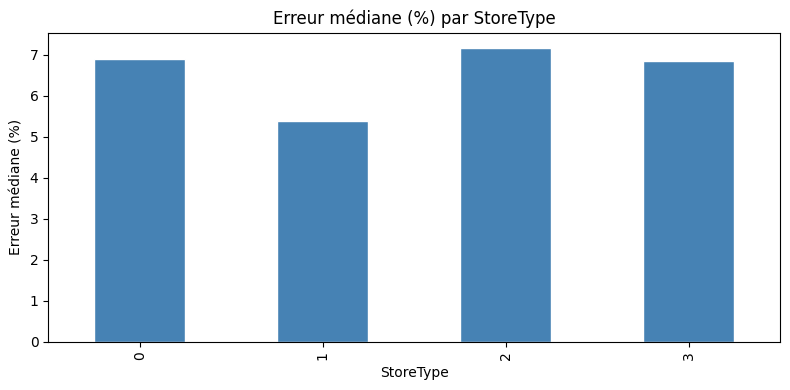

In [13]:
# Erreur par type de store
val_df.groupby('StoreType')['Error_pct'].median().plot(kind='bar', figsize=(8,4),
    color='steelblue', edgecolor='white', title='Erreur médiane (%) par StoreType')
plt.ylabel('Erreur médiane (%)')
plt.tight_layout()
plt.show()

## 10. Prochaines étapes

| Amélioration | Complexité | Impact estimé |
|---|---|---|
| Optimisation hyperparamètres avec Optuna | Moyen | +++ |
| Ajout features météo externes | Élevé | ++ |
| Ensemble LightGBM + XGBoost | Moyen | ++ |
| Features de tendance par store | Faible | + |
| Modèle spécifique par StoreType | Faible | + |